In [14]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.utils.data as dataloader
import torch.nn as nn
import torch.nn.functional as F

import os

import matplotlib.pyplot as plt
import numpy as np

In [15]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [16]:
#define variables

# Updated for better CIFAR-10 performance

batch_size = 64
img_size = 32
patch_size = 4
num_channels = 3
patch_num = (img_size // patch_size) ** 2 # 64
embed_dim = 256     # Increased from 128
num_heads = 16      # Increased from 1
mlp_nodes = 512     # Increased from 64

In [17]:
class PatchEmbedding(nn.Module):
    def __init__(self):
      super().__init__()
      self.patch_embed=nn.Conv2d(num_channels,embed_dim,kernel_size=patch_size,stride=patch_size )

    def forward(self,x):
      x=self.patch_embed(x)
      # print(x.shape) # torch.Size([1, 768, 14, 14]) its shape is (batch_size,embed_dim,img size)
      x=x.flatten(2)
      x=x.transpose(1,2) # torch shape is ( batch size, img size flattened, embed dim)
      # print(x.shape)( 1,198 which is no of patches ie 14*14 , embed dim of each patches=768)
      return x




In [18]:
"""Class for Transformer encoder
-Residual incomming from patch embedding
- Layer Normalization
- Multihead Attention
- Residual from multi head attention
- Layer Normalization
-MLP with GELU activation"""


class TransformerEncoder(nn.Module):
  def __init__(self):
     super().__init__()
     self.layer_norm_1 = nn.LayerNorm(embed_dim)
     self.self_attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
     self.layer_norm_2 = nn.LayerNorm(embed_dim)
     self.multi_layer_perceptron = nn.Sequential(
            nn.Linear(embed_dim, mlp_nodes),
            nn.GELU(),
            nn.Linear(mlp_nodes, embed_dim)
        )
  def forward(self, x):
        residual_1 = x
        attention_output = self.self_attention(self.layer_norm_1(x),self.layer_norm_1(x),self.layer_norm_1(x))[0]
        x = attention_output + residual_1
        residual_2 = x
        mlp_output = self.multi_layer_perceptron(self.layer_norm_2(x))
        x = mlp_output + residual_2
        return x




In [19]:
# Class for MLP head for classification

class MLP_Head(nn.Module):
  def __init__(self):
     super().__init__()
     self.layernorm1=nn.LayerNorm(embed_dim)
     self.mlp.head=nn.Sequential(
         nn.Linear(embed_dim,num_classes)
     )

  def forward(self,x):
    x=x[:,0]
    x=self.layernorm1(x)
    x=self.mlphead(x)
    return x


In [20]:
# # Random Masking

# def random_masking(x, mask_ratio=0.75):
#     batch, num_patches, _ = x.shape
#     num_tokens_to_keep = int(num_patches*(1-mask_ratio))

#     noise = torch.rand(batch, num_patches, device=x.device)

#     sorted_idx=torch.argsort(noise, dim=1)
#     selected_idx=sorted_idx[:, :num_tokens_to_keep]

#     restore_idx=torch.argsort(sorted_idx, dim=1)

#     selected_idx_repeat=selected_idx.unsqueeze(-1).repeat(1,1,embed_dim)

#     x_masked=torch.gather(x, dim=1, index=selected_idx_repeat)

#     mask=torch.ones([batch_size,num_patches], device=x.device)
#     mask[:, :num_tokens_to_keep]=0

#     mask=torch.gather(mask, dim=1, index=restore_idx)
#     return x_masked, mask,restore_idx






In [21]:
def random_masking(x, mask_ratio=0.5):
    batch, num_patches, embed_dim = x.shape # Use local embed_dim
    num_tokens_to_keep = int(num_patches * (1 - mask_ratio))

    noise = torch.rand(batch, num_patches, device=x.device)
    sorted_idx = torch.argsort(noise, dim=1)
    selected_idx = sorted_idx[:, :num_tokens_to_keep]
    restore_idx = torch.argsort(sorted_idx, dim=1)

    # Use the local 'batch' variable here to avoid crashes
    selected_idx_repeat = selected_idx.unsqueeze(-1).repeat(1, 1, embed_dim)
    x_masked = torch.gather(x, dim=1, index=selected_idx_repeat)

    # FIX: Use 'batch' instead of 'batch_size'
    mask = torch.ones([batch, num_patches], device=x.device)
    mask[:, :num_tokens_to_keep] = 0
    mask = torch.gather(mask, dim=1, index=restore_idx)

    return x_masked, mask, restore_idx

## MAE Encoder

In [22]:
class MAE_Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = PatchEmbedding()
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # pos_embed: 16 patches + 1 cls token
        self.pos_embed = nn.Parameter(torch.zeros(1, patch_num + 1, embed_dim))
        self.blocks = nn.Sequential(*[TransformerEncoder() for _ in range(4)])

        torch.nn.init.normal_(self.pos_embed, std=.02)


    def forward(self, x, mask_ratio=0.75):
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :] # Add patch pos embed

        # Masking happens here!
        x, mask, restore_idx = random_masking(x, mask_ratio)

        # Add CLS token after masking
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = self.blocks(x)
        return x, mask, restore_idx

## MAE Decoder


In [23]:
class MAE_Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Decoder often uses a smaller dimension (e.g., 16) to be efficient
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, patch_num + 1, embed_dim))
        self.decoder_blocks = nn.Sequential(*[TransformerEncoder() for _ in range(2)])

        torch.nn.init.normal_(self.decoder_pos_embed, std=.02)

        # Reconstruction head: num_channels * patch_size**2 pixels
        self.pred_head = nn.Linear(embed_dim, num_channels * patch_size**2)

    def forward(self, x, restore_idx):
        # 1. Add mask tokens to fill the sequence back to 16 patches
        mask_tokens = self.mask_token.repeat(x.shape[0], restore_idx.shape[1] + 1 - x.shape[1], 1)
        x_combined = torch.cat([x[:, 1:, :], mask_tokens], dim=1) # skip cls

        # 2. Unshuffle to original order
        x_unshuffled = torch.gather(x_combined, dim=1, index=restore_idx.unsqueeze(-1).repeat(1, 1, embed_dim))

        # 3. Add CLS and Pos Embed
        x = torch.cat([x[:, :1, :], x_unshuffled], dim=1)
        x = x + self.decoder_pos_embed

        # 4. Decode and Predict pixels
        x = self.decoder_blocks(x)
        return self.pred_head(x[:, 1:, :]) # [batch, num_patches, num_channels * patch_size**2]

##Bringing it all together (The Loss)
In MAE, the loss is calculated only on the masked patches. You compare the predicted pixels to the original pixels of those patches using Mean Squared Error (MSE).

In [24]:
class MAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MAE_Encoder()
        self.decoder = MAE_Decoder()

    def patchify(self, imgs):
        """Converts [B, C, H, W] to [B, num_patches, C*patch_size*patch_size]"""
        # H=W=img_size, C=num_channels are global variables
        batch_size = imgs.shape[0]
        num_patches_h = img_size // patch_size
        num_patches_w = img_size // patch_size

        # Reshape to (batch_size, num_channels, num_patches_h, patch_size, num_patches_w, patch_size)
        x = imgs.reshape(batch_size, num_channels, num_patches_h, patch_size, num_patches_w, patch_size)

        # Permute to (batch_size, num_patches_h, num_patches_w, num_channels, patch_size, patch_size)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()

        # Reshape to (batch_size, total_num_patches, num_channels * patch_size * patch_size)
        x = x.reshape(batch_size, num_patches_h * num_patches_w, num_channels * patch_size * patch_size)
        return x

    def forward(self, imgs, mask_ratio=0.75):
        # 1. Encode
        latent, mask, ids_restore = self.encoder(imgs, mask_ratio)
        # 2. Decode
        pred = self.decoder(latent, ids_restore)
        # 3. Get target pixels
        target = self.patchify(imgs)

        # 4. Calculate MSE Loss only on masked patches
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum() # Average over masked patches only

        return loss, pred, mask

## Load the CIFAR dataset

In [25]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Standard for CIFAR
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = dataloader.DataLoader(train_dataset, batch_size=64, shuffle=True)

## Training (optimizer and model)

In [26]:
model = MAE().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)

print(f"MAE Model loaded on {device}")

MAE Model loaded on cuda


## Training Loop

In [27]:
epochs = 100
model.train()

for epoch in range(epochs):
    total_loss = 0
    for i, (imgs, _) in enumerate(train_loader):
        imgs = imgs.to(device)

        optimizer.zero_grad()
        loss, pred, mask = model(imgs)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/100], Loss: 0.1446
Epoch [2/100], Loss: 0.0932
Epoch [3/100], Loss: 0.0832
Epoch [4/100], Loss: 0.0801
Epoch [5/100], Loss: 0.0782
Epoch [6/100], Loss: 0.0771
Epoch [7/100], Loss: 0.0760
Epoch [8/100], Loss: 0.0754
Epoch [9/100], Loss: 0.0746
Epoch [10/100], Loss: 0.0739
Epoch [11/100], Loss: 0.0738
Epoch [12/100], Loss: 0.0730
Epoch [13/100], Loss: 0.0729
Epoch [14/100], Loss: 0.0725
Epoch [15/100], Loss: 0.0720
Epoch [16/100], Loss: 0.0717
Epoch [17/100], Loss: 0.0714
Epoch [18/100], Loss: 0.0710
Epoch [19/100], Loss: 0.0709
Epoch [20/100], Loss: 0.0707
Epoch [21/100], Loss: 0.0705
Epoch [22/100], Loss: 0.0704
Epoch [23/100], Loss: 0.0701
Epoch [24/100], Loss: 0.0701
Epoch [25/100], Loss: 0.0696
Epoch [26/100], Loss: 0.0696
Epoch [27/100], Loss: 0.0695
Epoch [28/100], Loss: 0.0694
Epoch [29/100], Loss: 0.0693
Epoch [30/100], Loss: 0.0691
Epoch [31/100], Loss: 0.0689
Epoch [32/100], Loss: 0.0691
Epoch [33/100], Loss: 0.0688
Epoch [34/100], Loss: 0.0688
Epoch [35/100], Loss: 0

## Visualize the Results
We want to see the Original Image, the Masked Image, and the Reconstructed Image side-by-side.

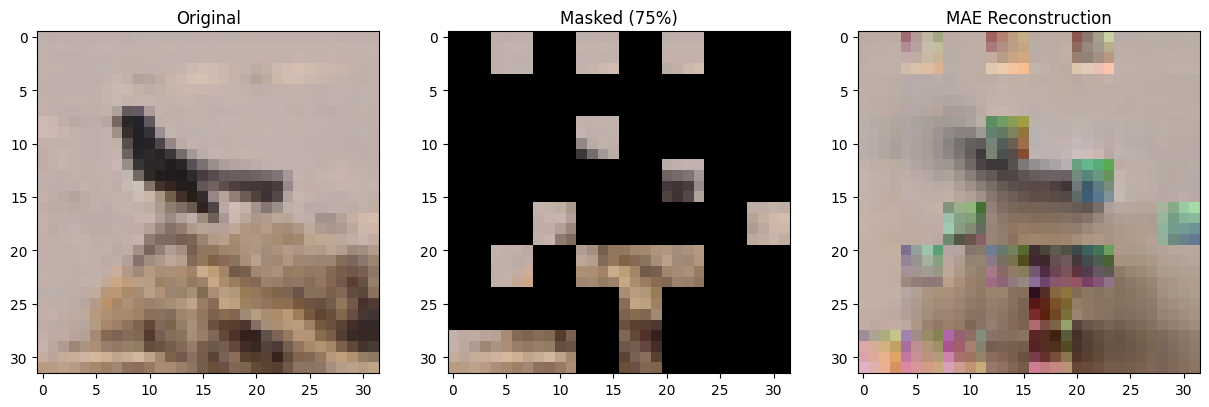

In [28]:
def visualize_mae(model, imgs):
    model.eval()
    with torch.no_grad():
        loss, pred, mask = model(imgs.to(device))

    # Get relevant global variables
    current_img_size = img_size
    current_patch_size = patch_size
    current_num_channels = num_channels
    num_patches_h = current_img_size // current_patch_size
    num_patches_w = current_img_size // current_patch_size

    # 1. Prepare Original
    # For color images, permute from [C, H, W] to [H, W, C]
    orig = imgs[0].permute(1, 2, 0).cpu().numpy()
    # Denormalize for plotting
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    orig = orig * std + mean
    orig = np.clip(orig, 0, 1) # Ensure values are in [0, 1]

    # 2. Prepare Masked (using the mask returned by the model)
    # This logic turns the mask into a img_size x img_size visual overlay
    mask_visual = mask[0].reshape(num_patches_h, num_patches_w) \
                          .repeat_interleave(current_patch_size, 0) \
                          .repeat_interleave(current_patch_size, 1) \
                          .cpu().numpy()

    # Apply mask to original image (denormalized)
    masked_img_tensor = imgs[0].cpu() # shape [C, H, W]
    # Denormalize from [-1, 1] to [0, 1]
    masked_img_tensor = masked_img_tensor * torch.tensor(std).unsqueeze(-1).unsqueeze(-1) + torch.tensor(mean).unsqueeze(-1).unsqueeze(-1)
    masked_img_tensor = torch.clamp(masked_img_tensor, 0, 1) # clip to [0, 1]

    # Expand mask_visual to have num_channels for element-wise multiplication
    mask_visual_expanded = np.expand_dims(mask_visual, axis=0) # shape [1, H, W]
    mask_visual_expanded = np.repeat(mask_visual_expanded, current_num_channels, axis=0) # shape [C, H, W]

    masked_img = masked_img_tensor.numpy() * (1 - mask_visual_expanded) # apply mask
    masked_img = masked_img.transpose(1, 2, 0) # permute to [H, W, C]

    # 3. Prepare Reconstruction
    # pred shape: [batch, patch_num, num_channels * patch_size * patch_size]
    # Reverse patchify: reshape, then permute
    recon_patches = pred[0].reshape(num_patches_h, num_patches_w, current_num_channels, current_patch_size, current_patch_size)
    recon = recon_patches.permute(2, 0, 3, 1, 4).contiguous() # permute to [C, num_patches_h, patch_size, num_patches_w, patch_size]
    recon = recon.reshape(current_num_channels, current_img_size, current_img_size).cpu()

    # Denormalize recon
    recon = recon * torch.tensor(std).unsqueeze(-1).unsqueeze(-1) + torch.tensor(mean).unsqueeze(-1).unsqueeze(-1)
    recon = torch.clamp(recon, 0, 1).permute(1, 2, 0).numpy() # permute to [H, W, C]

    # Plot
    plt.figure(figsize=(15, 5)) # Adjusted figsize for 3 images
    plt.subplot(1, 3, 1); plt.imshow(orig); plt.title("Original")
    plt.subplot(1, 3, 2); plt.imshow(masked_img); plt.title("Masked (75%)")
    plt.subplot(1, 3, 3); plt.imshow(recon); plt.title("MAE Reconstruction")
    plt.show()

# Run visualization on a batch of images from the train_loader
# Get a single batch of images for visualization
imgs, _ = next(iter(train_loader))
visualize_mae(model, imgs)

In [29]:
# NEW CELL 1: Setup
!pip install ultralytics
from ultralytics import YOLO
import cv2
from PIL import Image

# Load the detector
yolo_model = YOLO('yolov8n.pt')

def prepare_custom_image(image_path):
    img = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    return transform(img).unsqueeze(0).to(device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


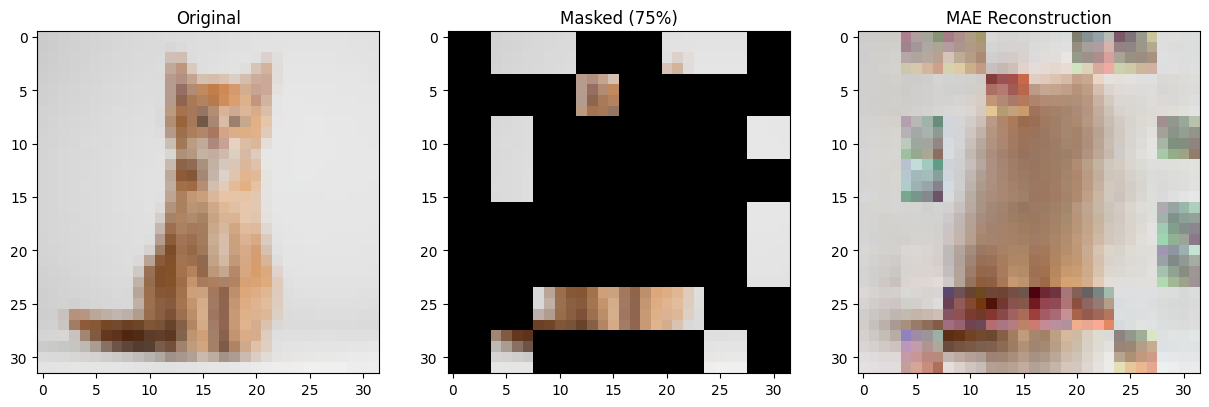

In [31]:
# NEW CELL 2: Run Inference
# Upload your file to Colab first!
my_image_path = 'cat.jpg'

# Option A: Just use the whole image resized
input_tensor = prepare_custom_image(my_image_path)

# Option B: Use YOLO to find an object and crop it
# results = yolo_model(my_image_path)
# ... (use the cropping logic from the previous message) ...

model.eval() # Put model in evaluation mode
with torch.no_grad():
    loss, pred, mask = model(input_tensor, mask_ratio=0.75)

# Use your existing visualization function to see the result
visualize_mae(model, input_tensor.cpu())